This project performs Exploratory Data Analysis (EDA) on the Netflix dataset. 
The objective is to analyze trends in movies and TV shows, understand content distribution, 
and identify patterns in genres, countries, and release years.

The dataset contains information about Netflix content including:
- Type (Movie / TV Show)
- Title
- Director
- Country
- Release Year
- Rating
- Duration
- Genre

This dataset helps analyze global content trends on Netflix.

In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Before cleaning
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(8807, 12)
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


### Before Cleaning:
- Missing values present in director, country, cast, and date_added
- Dataset contains categorical and numerical data
- Some columns contain multiple values (genres, cast)

In [4]:
# Fill missing values
df.fillna('Unknown', inplace=True)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year & month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Rename column
df.rename(columns={'listed_in':'genre'}, inplace=True)

In [6]:
# Convert date_added to datetime (if not already done)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Fill missing date_added with most frequent date
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

# Recreate year_added and month_added properly
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

/tmp/ipykernel_55/1519327368.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)


In [7]:
# After cleaning
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genre           0
description     0
year_added      0
month_added     0
dtype: int64


# Visualization 

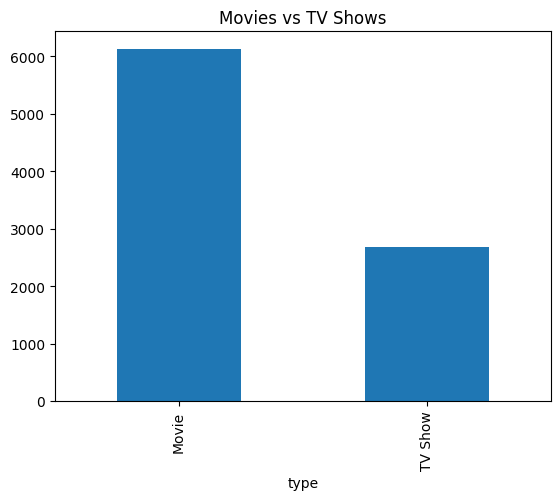

In [9]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

Insight:

Movies are more common than TV Shows on Netflix.

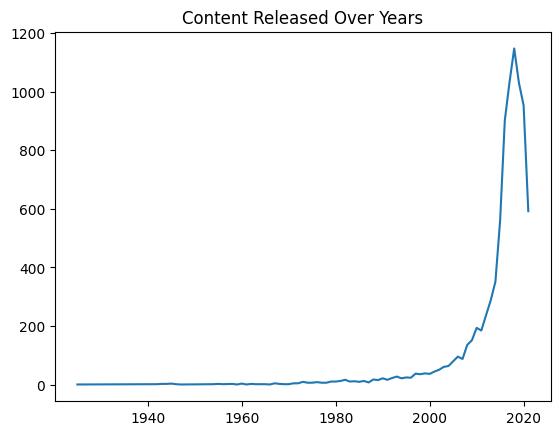

In [10]:
year_counts = df['release_year'].value_counts().sort_index()

plt.plot(year_counts.index, year_counts.values)
plt.title("Content Released Over Years")
plt.show()

Insight:

Content production increased rapidly after 2010.

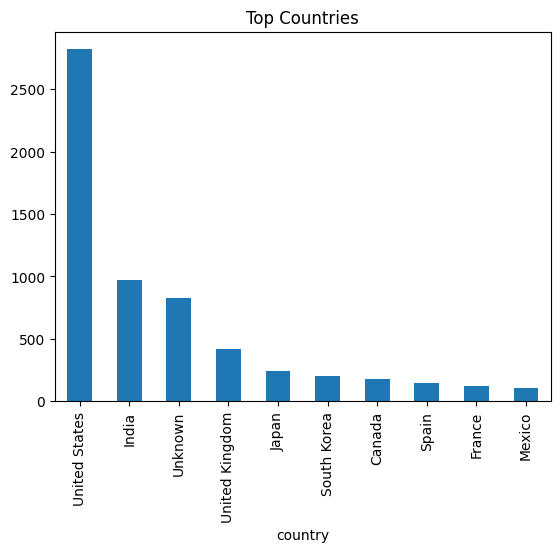

In [11]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.show()

Insight:

USA produces the most content.

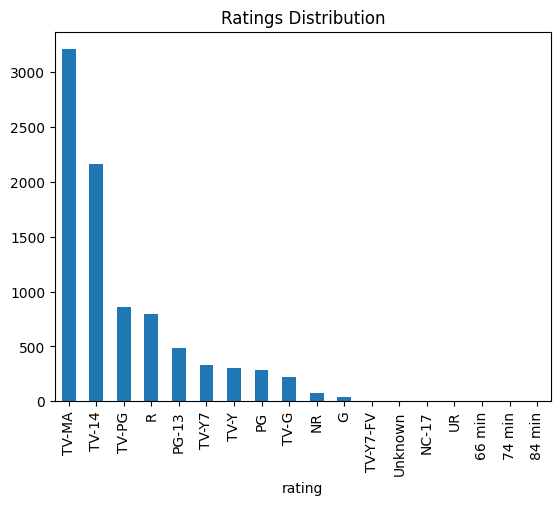

In [12]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

Insight:

TV-MA and TV-14 are most common ratings.

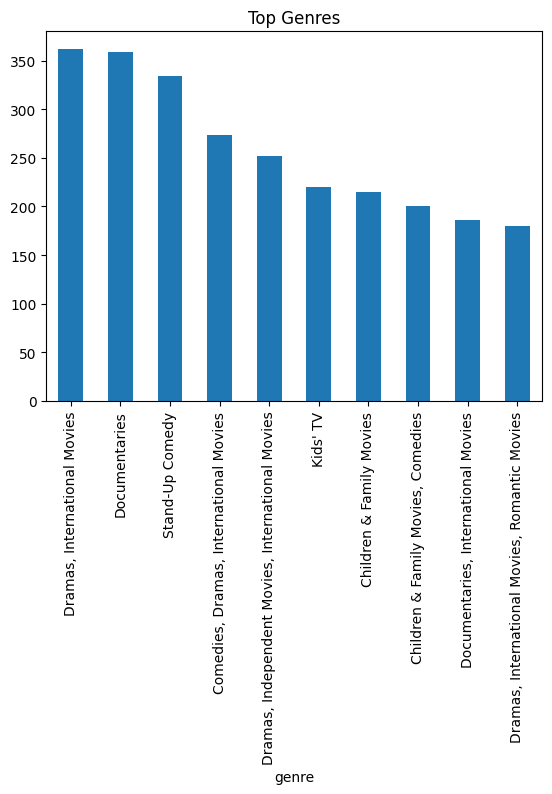

In [13]:
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

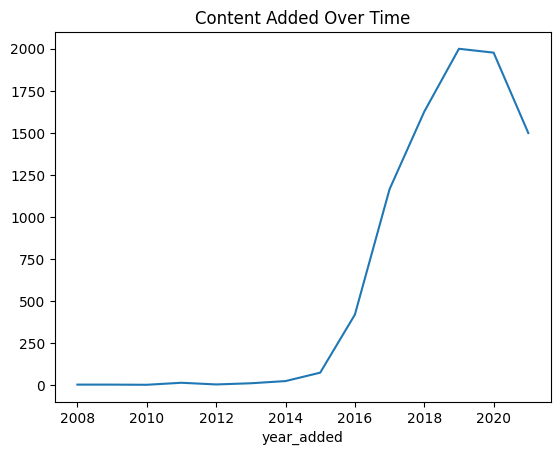

In [14]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added Over Time")
plt.show()

Insight:

Netflix expanded rapidly in recent years.

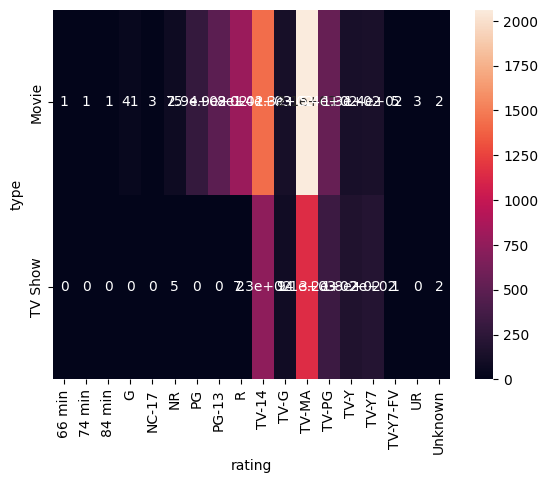

In [15]:
import seaborn as sns

pivot = df.pivot_table(index='type', columns='rating', aggfunc='size', fill_value=0)

sns.heatmap(pivot, annot=True)
plt.show()

Insight:

Movies and TV Shows differ in rating distribution.

### Conclusion

- Netflix content has grown significantly after 2010
- Movies dominate the platform compared to TV shows
- USA is the leading content producer
- Drama and Comedy are the most popular genres
- Content addition peaked in recent years

Overall, Netflix shows a strong trend of rapid expansion and global content diversity.